In [10]:
import os
os.chdir("D:/文章返修/source data/Figure_2/Panel_D")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pandas as pd

In [6]:
def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf >= s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

In [3]:
file_dir = "./"

rna_pedv_cell_all = np.loadtxt(file_dir + '1_alpha_PEDV_PRJCA026550-VeroE6-12h-rnaseq.1nt.none.matrix', usecols=[0,1,2]
                  , dtype=[('S','<i4'),('E','<i4'),('value','<f8')])

rna_seq_24_all = np.loadtxt(file_dir + '2_beta_SARS-CoV-2-9_all-rep-rna.1nt.none.matrix', usecols=[0,1,2]
                  , dtype=[('S','<f8'),('E','<f8'),('value','<f8')])

rna_ibv = np.loadtxt(file_dir +  '3_gama_IBV-6_SRR10273273.1nt.none.matrix', usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])

rna_pdcov_cell_all = np.loadtxt(file_dir + '4_delta_PDCoV_PRJCA026550-LLCPK1-18h-rnaseq.1nt.none.matrix', usecols=[0,1,2]
                  , dtype=[('S','<i4'),('E','<i4'),('value','<f8')])

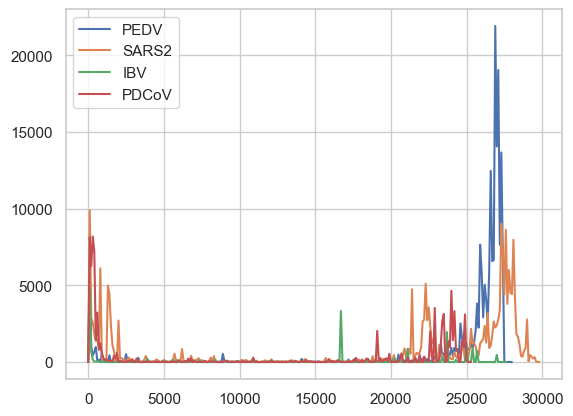

In [9]:
datas = []
sns.set_theme(style="whitegrid")
plt.figure()
rna_c, rna_nc, hist_data = classify_rna_data(rna_pedv_cell_all, 100, 10, 5, [100,2000])
plt.plot([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)], label = 'PEDV')
datas.append([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)])

rna_c, rna_nc, hist_data = classify_rna_data(rna_seq_24_all, 100, 10, 5, [100,2000])
plt.plot([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)], label = 'SARS2')
datas.append([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)])

rna_c, rna_nc, hist_data = classify_rna_data(rna_ibv, 100, 10, 5, [100,2000])
plt.plot([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)], label = 'IBV')
datas.append([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)])

rna_c, rna_nc, hist_data = classify_rna_data(rna_pdcov_cell_all, 100, 10, 5, [100,2000])
plt.plot([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)], label = 'PDCoV')
datas.append([sum(hist_data[i:i+20]) for i in range(0, len(hist_data), 20)])

plt.legend()
plt.xticks(np.arange(0,301,50), np.arange(0,301,50)*100)
plt.savefig("rna_curve.pdf",format="pdf")

In [12]:
df = pd.DataFrame({"PEDV":np.array(datas[0])
#                   "SARS-CoV-2":np.array(datas[1]),
#                   "IBV":np.array(datas[2]),
#                   "PDCoV":np.array(datas[3]
})

df.to_excel('pedv.xlsx', index=False)